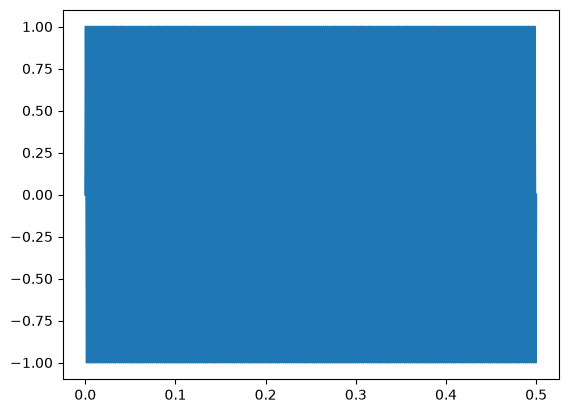

[1.         1.05946309 1.12246205 1.18920712 1.25992105 1.33483985
 1.41421356 1.49830708 1.58740105 1.68179283 1.78179744 1.88774863
 2.        ]
False
True
[ True  True  True ...  True  True  True]


44100
405891
9.203877551020408


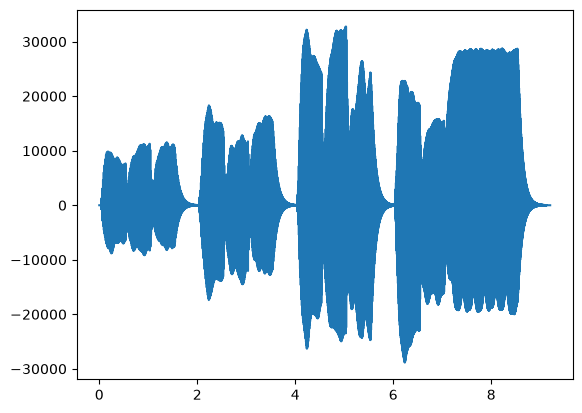

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.io import wavfile

f=44100 #Fréquence d'échantillonnage en Hz
la=440 #Fréquence du la en Hz
do=523.25 #Fréquence du do en Hz

#2.1

#1 La fréquence d'échantillonnage vaut 44.1 kHz, il faut donc 44100 échantillons pour un extrait d'une seconde.

#2
def position(phi,t) :
    return np.sin(2*np.pi*phi*t)

#3

time=0.5 #Temps de l'extrait en secondes
t=np.linspace(0,time,int(time*f)) #échantillons 

plt.close(1)
plt.figure(1)
plt.plot(t,position(la,t)) #On trace la position en fonction du temps
plt.show()

display(Audio(position(la,t),rate=f))

#2.2

def sine(freq, duration, amplitude) :
    timelist=np.linspace(0,duration,int(f*duration)) #On crée le vecteur des temps
    return amplitude*np.sin(2*np.pi*freq*timelist)

#2.3

def sine_linear(freq1,freq2,duration) :
    timelist=np.linspace(0,duration,int(f*duration))
    freq_variable=(freq2-freq1)/duration*timelist+freq1 #On crée un vecteur des fréquences qui varient linéairement avec le temps
    phase=2*np.pi*((freq2-freq1)/(2*duration)*timelist**2+freq1*timelist) #On a calculé à la main l'intégrale entre 0 et timelist de la fonction freq_variable
    return np.sin(phase)

display(Audio(sine_linear(20,5000,2),rate=f)) #On prend un exemple pour freq_1=20 Hz, freq_2=5000Hz, duration=2s

#3.1 Pour modifier l'amplitude de la sinusoïde, on peut multiplier l'amplitude initiale par un coefficient qui dépend du temps.

#3.2 et 3.3

def crescendo_sine(freq, duration,increase):
    t=np.linspace(0,duration,int(f*duration)) #Tableau des temps
    coef=int(increase)*t/duration+(1-int(increase))*((duration-t)/duration) #Coefficient d'amplitude, dont l'expression dépend de la valeur de increase
    return coef*np.sin(2*np.pi*freq*t)

display(Audio(crescendo_sine(la,2,True), rate=f))
display(Audio(crescendo_sine(la,2,False), rate=f))

#3.4 Si le signal est périodique, on pourrait le décomposer en série de Fourier, et appliquer la méthode précédente à chaque coefficient de Fourier...

#4

def concatenation(f1,f2,duration1,duration2):
    t1=np.linspace(0, duration1,int(f*duration1))
    signal1=np.sin(2*np.pi*f1*t1)
    t2=np.linspace(duration1, duration1+duration2, int(f*duration2))
    signal2=np.sin(2*np.pi*f2*t2)
    return np.concatenate((signal1,signal2)) #On a créé deux vecteurs donnant les signaux donnant les deux notes, puis on les concatène.

la_do=concatenation(la,do,1,1)
display(Audio(la_do, rate=f))

#5

def float_to_int16(as_float):
    as_bin = (32768*as_float).astype(np.int16)
    return as_bin

#6

#6.1 

ratios=2**(np.arange(0,13)/12) #On crée un tableau d'entiers entre 0 et 12 inclus, puis on lui applique des fonctions pour obtenir le tableau désiré
print(ratios)

#6.2 et 6.3

def freq_from_name(name):
    dico_note={"do":0, "do dièse":1, "ré":2, "ré dièse":3, "mi":4, "fa":5, "fa dièse":6, "sol":7, "sol dièse":8, "la":9, "la dièse":10, "si":11, "do'":12}
    #On crée un dictionnaire qui à chaque note associe sa position dans la gamme, pour pouvoir utiliser ratio
    freq_do=261.63 #Puisque le la correspond à 440 Hz, on trouve que le do correspond à cette fréquence en multipliant 440 par 2**(-9/12)
    return freq_do*ratios[dico_note[name]]

print(freq_from_name('la')==440) #Avec mon procédé, on ne tombe pas pile sur 440 Hz à causes de calculs intermédiaires, mais on est exacts pour le do.
print(np.isclose(440, freq_from_name('la'),0.001))

#7 Physiquement, un accord est la somme des signaux correspondant à chaque note. Ainsi, pour avoir le signal temporel correspondant à un accord, il suffit de créer le vecteur somme des tableaux des notes qui la composent.

#8 
wavfile.write("sample.wav",f,la_do) #On reprend le fichier la_do de la question 4, et on écrit un fichier à la fréquence d'échantillonnage f=44100 Hz.
restored=wavfile.read("sample.wav")[1]
print(restored==la_do) #On obtient True : c'est bon, le fichier lu est bien le même que l'original

#9

#9.1 
data=wavfile.read("media/sounds-cello.wav")
#9.2
display(Audio(data[1],rate=f))
#9.3
samplerate=data[0]
print(samplerate) 
#9.4
nb_echantillons=len(data[1])
print(nb_echantillons)
#9.5
duree=nb_echantillons/samplerate
print(duree) #En divisant le nombre d'échantillons total par le nombre d'échantillons par seconde, on obtient bien la durée totale du morceau.
#9.6
temps=np.linspace(0,duree,nb_echantillons) #On crée le tableau des temps (abscisses), en divisant l'intervalle [0, durée du morceau] en autant de morceaux qu'il n'y a d'échantillons en tout
plt.figure(1)
plt.plot(temps,data[1])
plt.show()

#10

#Exercice v1

delay=2
main_ratio,delayed_ratio=0.7,0.3
offset=delay*f 

delayed_data=np.concatenate((np.zeros(offset),data[1])) #On crée d'abord un signal décalé, en ajoutant l'équivalent de 2 secondes de silence à l'audio original (i.e. on a ajouté offset zéros au début).
delayed_cropped_data=delayed_data[:nb_echantillons] #On "coupe" l'audio qui dépasse, pour que la partie écho soit de même longueur que l'audio original
data_echoed=main_ratio*data[1]+delayed_ratio*delayed_cropped_data #Pour obtenir le signal avec effet écho, on superpose le signal original avec l'écho délayé, et on pondère ces deux signaux pour que l'écho soit moins fort
display(Audio(data_echoed,rate=f))

#Exercice v2

#Cette fois-ci, on complète le signal original avec des zéros à la fin pour qu'il soit de même longueur que delayed_data
data_extended=np.concatenate((data[1],np.zeros(offset)))
data_echoed_longer=main_ratio*data_extended+delayed_ratio*delayed_data
display(Audio(data_echoed_longer,rate=f))

#11

#11.1

#Pour produire un son une octave au-dessus "artificiellement", on peut enlever un échantillon sur deux. Le samplerate restant inchangé, l'extrait sera "lu deux fois plus vite" (on aura néanmoins de la perte d'informations).

data2=data[1][::2] #On slice pour obtenir un élément sur 2 du tableau initial
display(Audio(data2,rate=f))

#11.2

#1
data3=np.zeros(int(2/3*nb_echantillons))

#2 
data3[::2]=data[1][::3] #On remplit les données de rang pair du nouveau tableau avec celles de rang multiple de 3 du tableau original
#3
data3[1:][::2]=data[1][1:][::3] #On remplit les données de rang impair du nouveau tableau (qu'on obtient en prenant un élément sur 2 du tableau data3 sans son premier élément) avec celles de rang congru à 1 modulo 3 du tableau original
display(Audio(data3,rate=f))








    

